In [1]:
import pandas as pd
import numpy as np
from ast import literal_eval
import seaborn as sns
from matplotlib import pyplot as plt
import scipy.stats as sts

In [2]:
import clickhouse_connect
import pandas as pd

# Подключение к ClickHouse
client = clickhouse_connect.get_client(
    host='clickhouse.lab.karpov.courses',
    port=8123,
    username='student',
    password='dpo_python_2020',
    database='simulator_20251120'
)

In [19]:
# Пример запроса
query1 = '''
with users_less_02 as

(select user_id from
(SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251120.feed_actions 
WHERE toDate(time) between '2025-10-26' and '2025-11-01'
    and exp_group in (2)
GROUP BY exp_group, user_id)
where (ctr between 0 and 0.2) and exp_group = 2)

select *
from simulator_20251120.feed_actions
WHERE user_id in (select user_id from users_less_02) and (toDate(time) between '2025-10-26' and '2025-11-01')'''

df1 = client.query_df(query1)

query2 = '''
with users_less_02 as

(select user_id from
(SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251120.feed_actions 
WHERE toDate(time) between '2025-10-26' and '2025-11-01'
    and exp_group in (2)
GROUP BY exp_group, user_id)
where (ctr between 0.2 and 0.4))

select *
from simulator_20251120.feed_actions
WHERE user_id in (select user_id from users_less_02) and (toDate(time) between '2025-10-26' and '2025-11-01')'''

df2 = client.query_df(query2)

In [20]:
from scipy.stats import chi2_contingency, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Предположим, у вас есть:
# left_peak_df - пользователи левого пика (CTR <= 0.2)
# right_peak_df - пользователи правого пика (0.25 <= CTR <= 0.45)

# Добавим метку пика
df1['peak'] = 'left'
df2['peak'] = 'right'

# Объединим данные для анализа
combined_df = pd.concat([df1, df2], ignore_index=True)

display(combined_df)

print(f"Левый пик: {len(df1)} пользователей")
print(f"Правый пик: {len(df2)} пользователей")

,user_id,post_id,action,time,gender,age,country,city,os,source,exp_group,peak
0,138454,2215,like,2025-10-30 02:49:04+03:00,0,21,Russia,Mineral’nyye Vody,Android,organic,2,left
1,31544,2321,view,2025-10-30 02:49:07+03:00,0,18,Russia,Bryansk,Android,ads,2,left
2,117002,2252,view,2025-10-30 02:49:08+03:00,1,31,Russia,Krasnokamensk,Android,organic,2,left
3,24473,2228,view,2025-10-30 02:49:09+03:00,0,37,Russia,Bataysk,Android,ads,2,left
4,31544,2215,view,2025-10-30 02:49:11+03:00,0,18,Russia,Bryansk,Android,ads,2,left
...,...,...,...,...,...,...,...,...,...,...,...,...
732285,112539,2473,view,2025-11-01 23:59:49+03:00,1,18,Russia,Tomsk,Android,organic,2,right
732286,332,2485,view,2025-11-01 23:59:50+03:00,0,26,Russia,Moscow,Android,ads,2,right
732287,119955,2223,view,2025-11-01 23:59:51+03:00,1,35,Russia,Ufa,iOS,organic,2,right
732288,11437,2539,view,2025-11-01 23:59:52+03:00,0,29,Russia,Saint Petersburg,iOS,ads,2,right


Левый пик: 433184 пользователей
Правый пик: 299106 пользователей



Анализ признака: gender


<Figure size 1000x600 with 0 Axes>

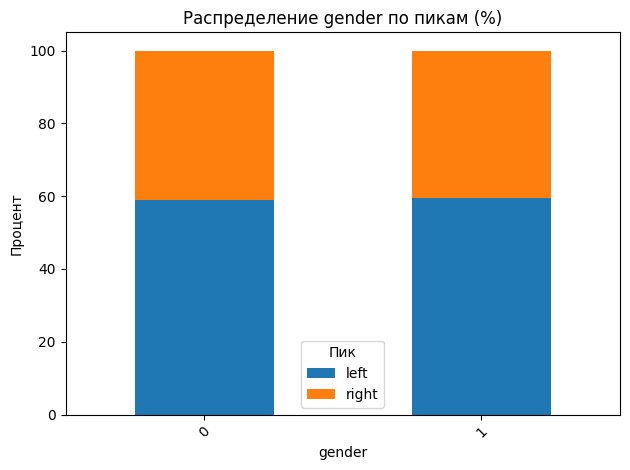

Хи-квадрат тест: p-value = 0.000000
Эффект размера (Cramér's V): 0.0063
Наиболее различающиеся категории:
  1: 55.6% (левый) vs 55.0% (правый)
  0: 44.4% (левый) vs 45.0% (правый)

Анализ признака: country


<Figure size 1000x600 with 0 Axes>

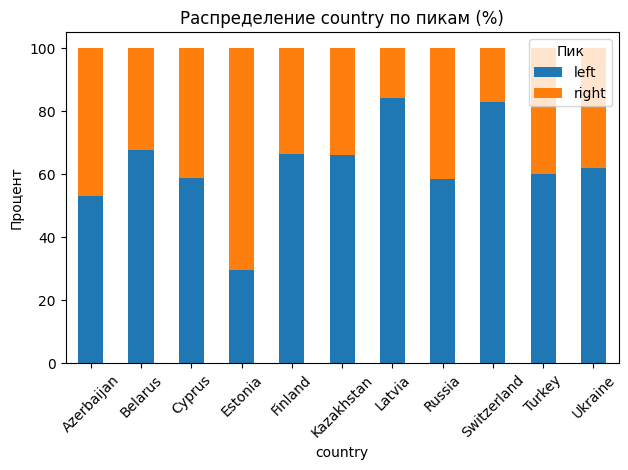

Хи-квадрат тест: p-value = 0.000000
Эффект размера (Cramér's V): 0.0480
Наиболее различающиеся категории:
  Russia: 86.8% (левый) vs 88.7% (правый)
  Belarus: 2.4% (левый) vs 1.6% (правый)
  Kazakhstan: 2.3% (левый) vs 1.7% (правый)
  Ukraine: 5.0% (левый) vs 4.5% (правый)
  Finland: 1.2% (левый) vs 0.9% (правый)

Анализ признака: city


<Figure size 1000x600 with 0 Axes>

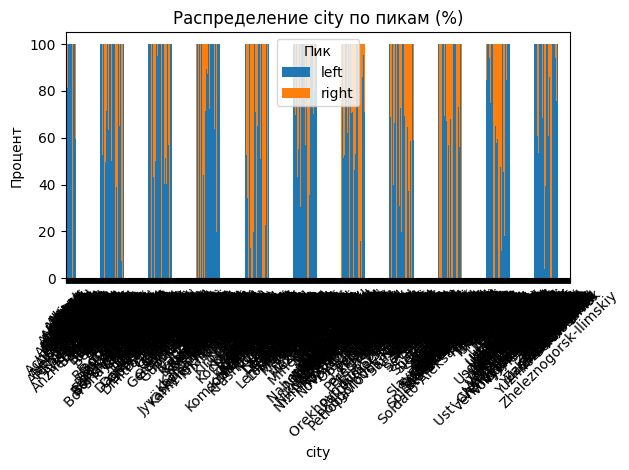

Хи-квадрат тест: p-value = 0.000000
Эффект размера (Cramér's V): 0.4448
Наиболее различающиеся категории:
  Moscow: 13.5% (левый) vs 14.3% (правый)
  Rostov: 1.2% (левый) vs 0.9% (правый)
  Vologda: 0.5% (левый) vs 0.1% (правый)
  Vladivostok: 0.6% (левый) vs 0.9% (правый)
  Tolyatti: 0.5% (левый) vs 0.2% (правый)

Анализ признака: os


<Figure size 1000x600 with 0 Axes>

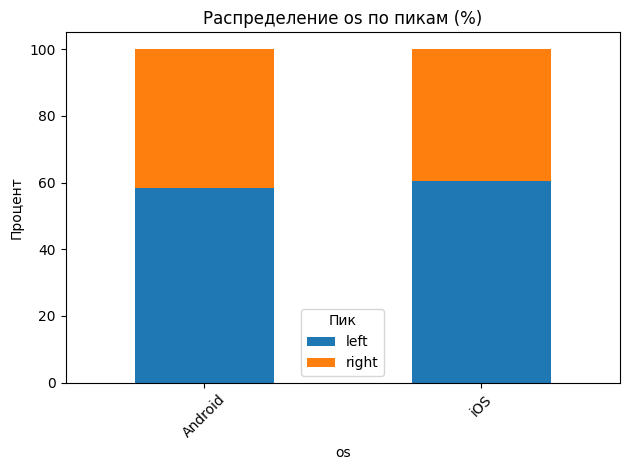

Хи-квадрат тест: p-value = 0.000000
Эффект размера (Cramér's V): 0.0189
Наиболее различающиеся категории:
  Android: 63.3% (левый) vs 65.1% (правый)
  iOS: 36.7% (левый) vs 34.9% (правый)

Анализ признака: source


<Figure size 1000x600 with 0 Axes>

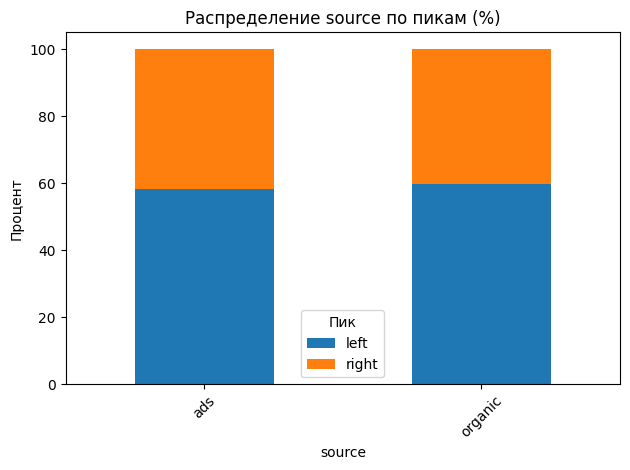

Хи-квадрат тест: p-value = 0.000000
Эффект размера (Cramér's V): 0.0164
Наиболее различающиеся категории:
  organic: 56.6% (левый) vs 55.0% (правый)
  ads: 43.4% (левый) vs 45.0% (правый)


In [21]:
def analyze_categorical_features(df, categorical_columns, target_column='peak'):
    """Анализ категориальных признаков между пиками"""
    
    results = {}
    
    for col in categorical_columns:
        print(f"\n{'='*50}")
        print(f"Анализ признака: {col}")
        print(f"{'='*50}")
        
        # Создаем таблицу сопряженности
        contingency_table = pd.crosstab(df[col], df[target_column])
        
        # Визуализация
        plt.figure(figsize=(10, 6))
        contingency_table_pct = contingency_table.div(contingency_table.sum(1), axis=0) * 100
        
        contingency_table_pct.plot(kind='bar', stacked=True)
        plt.title(f'Распределение {col} по пикам (%)')
        plt.ylabel('Процент')
        plt.xticks(rotation=45)
        plt.legend(title='Пик')
        plt.tight_layout()
        plt.show()
        
        # Статистическая значимость (Хи-квадрат)
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        
        print(f"Хи-квадрат тест: p-value = {p_value:.6f}")
        
        # Эффект размера (Cramér's V)
        n = contingency_table.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
        print(f"Эффект размера (Cramér's V): {cramers_v:.4f}")
        
        # Анализ наиболее различающихся категорий
        left_proportions = contingency_table['left'] / contingency_table['left'].sum()
        right_proportions = contingency_table['right'] / contingency_table['right'].sum()
        difference = (right_proportions - left_proportions).abs()
        
        top_differences = difference.nlargest(5)
        print("Наиболее различающиеся категории:")
        for category, diff in top_differences.items():
            left_pct = left_proportions.get(category, 0) * 100
            right_pct = right_proportions.get(category, 0) * 100
            print(f"  {category}: {left_pct:.1f}% (левый) vs {right_pct:.1f}% (правый)")
        
        results[col] = {
            'p_value': p_value,
            'cramers_v': cramers_v,
            'significant': p_value < 0.05,
            'top_differences': top_differences
        }
    
    return results

# Применяем к категориальным признакам
categorical_cols = ['gender', 'country', 'city', 'os', 'source']
categorical_results = analyze_categorical_features(combined_df, categorical_cols)

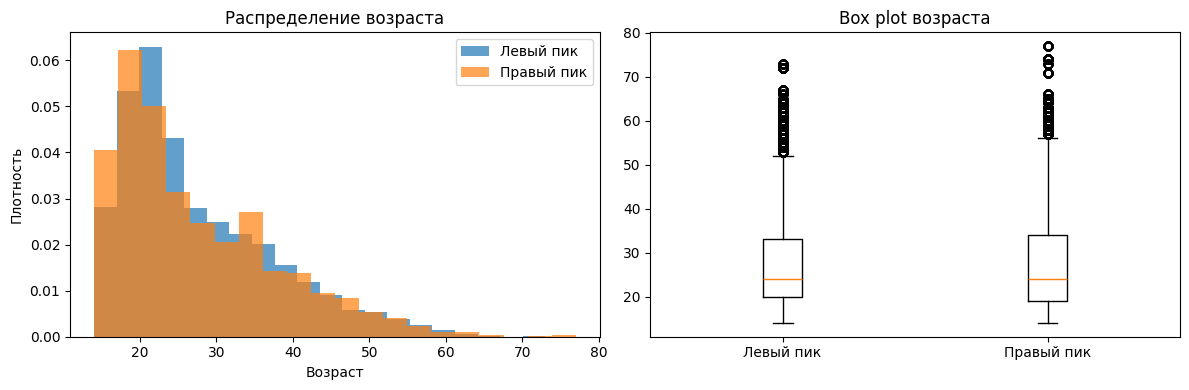

T-тест: p-value = 0.006691
U-тест Манна-Уитни: p-value = 0.000342
Средний возраст: 27.3 (левый) vs 27.4 (правый)
Медиана возраста: 24.0 (левый) vs 24.0 (правый)


In [22]:
def analyze_age_distribution(left_df, right_df):
    """Анализ распределения возраста между пиками"""
    
    plt.figure(figsize=(12, 4))
    
    # Гистограмма
    plt.subplot(1, 2, 1)
    plt.hist(left_df['age'], alpha=0.7, bins=20, label='Левый пик', density=True)
    plt.hist(right_df['age'], alpha=0.7, bins=20, label='Правый пик', density=True)
    plt.xlabel('Возраст')
    plt.ylabel('Плотность')
    plt.legend()
    plt.title('Распределение возраста')
    
    # Box plot
    plt.subplot(1, 2, 2)
    plot_data = [left_df['age'].dropna(), right_df['age'].dropna()]
    plt.boxplot(plot_data, labels=['Левый пик', 'Правый пик'])
    plt.title('Box plot возраста')
    
    plt.tight_layout()
    plt.show()
    
    # Статистические тесты
    t_stat, t_p = sts.ttest_ind(left_df['age'].dropna(), right_df['age'].dropna())
    u_stat, u_p = sts.mannwhitneyu(left_df['age'].dropna(), right_df['age'].dropna())
    
    print(f"T-тест: p-value = {t_p:.6f}")
    print(f"U-тест Манна-Уитни: p-value = {u_p:.6f}")
    print(f"Средний возраст: {left_df['age'].mean():.1f} (левый) vs {right_df['age'].mean():.1f} (правый)")
    print(f"Медиана возраста: {left_df['age'].median():.1f} (левый) vs {right_df['age'].median():.1f} (правый)")
    
    return {'t_test_p': t_p, 'u_test_p': u_p}

age_results = analyze_age_distribution(df1, df2)

<Figure size 1500x500 with 0 Axes>

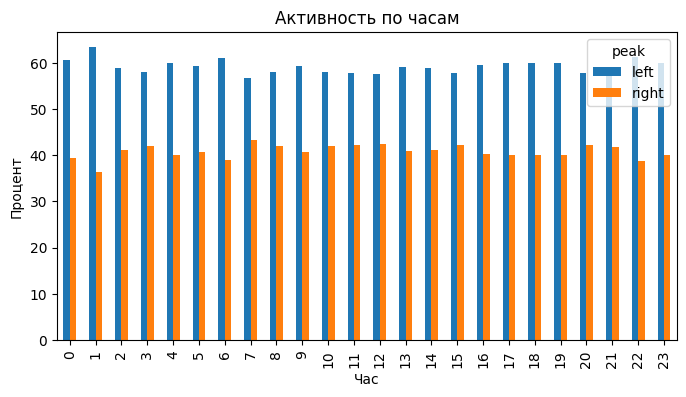

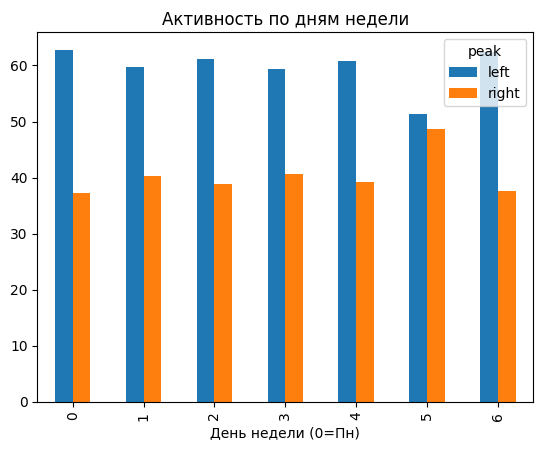

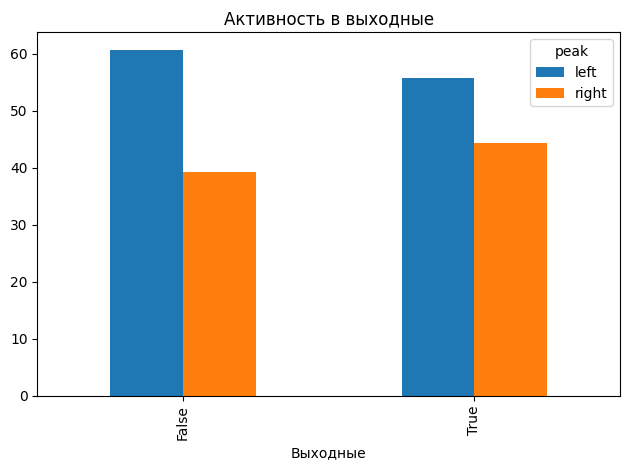

In [23]:
def analyze_time_patterns(df):
    """Анализ временных паттернов активности"""
    
    # Преобразуем время
    df['hour'] = pd.to_datetime(df['time']).dt.hour
    df['day_of_week'] = pd.to_datetime(df['time']).dt.dayofweek
    df['is_weekend'] = df['day_of_week'].isin([5, 6])
    
    # Анализ по часам
    plt.figure(figsize=(15, 5))
    

    hour_dist = pd.crosstab(df['hour'], df['peak'], normalize='index') * 100
    hour_dist.plot(kind='bar', figsize=(8, 4))
    plt.title('Активность по часам')
    plt.xlabel('Час')
    plt.ylabel('Процент')
    
 
    day_dist = pd.crosstab(df['day_of_week'], df['peak'], normalize='index') * 100
    day_dist.plot(kind='bar')
    plt.title('Активность по дням недели')
    plt.xlabel('День недели (0=Пн)')
    
   
    weekend_dist = pd.crosstab(df['is_weekend'], df['peak'], normalize='index') * 100
    weekend_dist.plot(kind='bar')
    plt.title('Активность в выходные')
    plt.xlabel('Выходные')
    
    plt.tight_layout()
    plt.show()
    
    return df


combined_df = analyze_time_patterns(combined_df)

In [24]:
def analyze_feature_combinations(df, top_features, max_combinations=5):
    """Анализ комбинаций признаков, создающих четкие сегменты"""
    
    significant_combinations = []
    
    # Анализ парных комбинаций категориальных признаков
    categorical_pairs = [
        ('country', 'os'),
        ('gender', 'source'), 
        ('country', 'source'),
        ('os', 'source')
    ]
    
    for feat1, feat2 in categorical_pairs:
        # Создаем комбинированный признак
        df['combo'] = df[feat1].astype(str) + '_' + df[feat2].astype(str)
        
        # Анализируем распределение
        combo_table = pd.crosstab(df['combo'], df['peak'])
        
        # Фильтруем значимые комбинации (минимум 20 пользователей в каждой группе)
        combo_table = combo_table[(combo_table['left'] >= 20) & (combo_table['right'] >= 20)]
        
        if len(combo_table) > 0:
            # Вычисляем долю правого пика
            combo_table['total'] = combo_table['left'] + combo_table['right']
            combo_table['right_ratio'] = combo_table['right'] / combo_table['total']
            
            # Находим комбинации с наибольшей разницей
            high_ratio = combo_table[combo_table['right_ratio'] > 0.7]
            low_ratio = combo_table[combo_table['right_ratio'] < 0.3]
            
            print(f"\nКомбинация {feat1} × {feat2}:")
            print("Преобладают в правом пике (>70%):")
            for idx, row in high_ratio.iterrows():
                print(f"  {idx}: {row['right_ratio']:.1%} ({row['total']} пользователей)")
            
            print("Преобладают в левом пике (<30%):")
            for idx, row in low_ratio.iterrows():
                print(f"  {idx}: {row['right_ratio']:.1%} ({row['total']} пользователей)")
    
    return significant_combinations

feature_combinations = analyze_feature_combinations(combined_df, ['country', 'os', 'source', 'gender'])


Комбинация country × os:
Преобладают в правом пике (>70%):
  Estonia_Android: 70.5% (434.0 пользователей)
Преобладают в левом пике (<30%):
  Belarus_Android: 26.5% (10216.0 пользователей)
  Latvia_iOS: 23.2% (298.0 пользователей)
  Switzerland_Android: 15.7% (490.0 пользователей)
  Switzerland_iOS: 19.9% (281.0 пользователей)

Комбинация gender × source:
Преобладают в правом пике (>70%):
Преобладают в левом пике (<30%):

Комбинация country × source:
Преобладают в правом пике (>70%):
  Latvia_ads: 72.6% (95.0 пользователей)
Преобладают в левом пике (<30%):
  Belarus_organic: 28.2% (9287.0 пользователей)
  Kazakhstan_organic: 29.2% (7796.0 пользователей)
  Switzerland_ads: 16.7% (336.0 пользователей)
  Switzerland_organic: 17.7% (435.0 пользователей)

Комбинация os × source:
Преобладают в правом пике (>70%):
Преобладают в левом пике (<30%):


In [25]:
def create_segment_profiles(left_df, right_df):
    """Создание профилей типичных пользователей для каждого пика"""
    
    print("ПРОФИЛЬ ЛЕВОГО ПИКА (CTR <= 0.2):")
    print("="*50)
    
    # Самые частые значения для левого пика
    for col in ['country', 'os', 'source', 'gender']:
        top_value = left_df[col].mode()[0] if len(left_df[col].mode()) > 0 else 'N/A'
        top_pct = (left_df[col] == top_value).mean() * 100
        print(f"{col}: {top_value} ({top_pct:.1f}%)")
    
    print(f"Средний возраст: {left_df['age'].mean():.1f}")
    print(f"Размер сегмента: {len(left_df)} пользователей")
    
    print("\nПРОФИЛЬ ПРАВОГО ПИКА (CTR 0.25-0.45):")
    print("="*50)
    
    # Самые частые значения для правого пика  
    for col in ['country', 'os', 'source', 'gender']:
        top_value = right_df[col].mode()[0] if len(right_df[col].mode()) > 0 else 'N/A'
        top_pct = (right_df[col] == top_value).mean() * 100
        print(f"{col}: {top_value} ({top_pct:.1f}%)")
    
    print(f"Средний возраст: {right_df['age'].mean():.1f}")
    print(f"Размер сегмента: {len(right_df)} пользователей")

create_segment_profiles(df1, df2)

ПРОФИЛЬ ЛЕВОГО ПИКА (CTR <= 0.2):
country: Russia (86.8%)
os: Android (63.3%)
source: organic (56.6%)
gender: 1 (55.6%)
Средний возраст: 27.3
Размер сегмента: 433184 пользователей

ПРОФИЛЬ ПРАВОГО ПИКА (CTR 0.25-0.45):
country: Russia (88.7%)
os: Android (65.1%)
source: organic (55.0%)
gender: 1 (55.0%)
Средний возраст: 27.4
Размер сегмента: 299106 пользователей


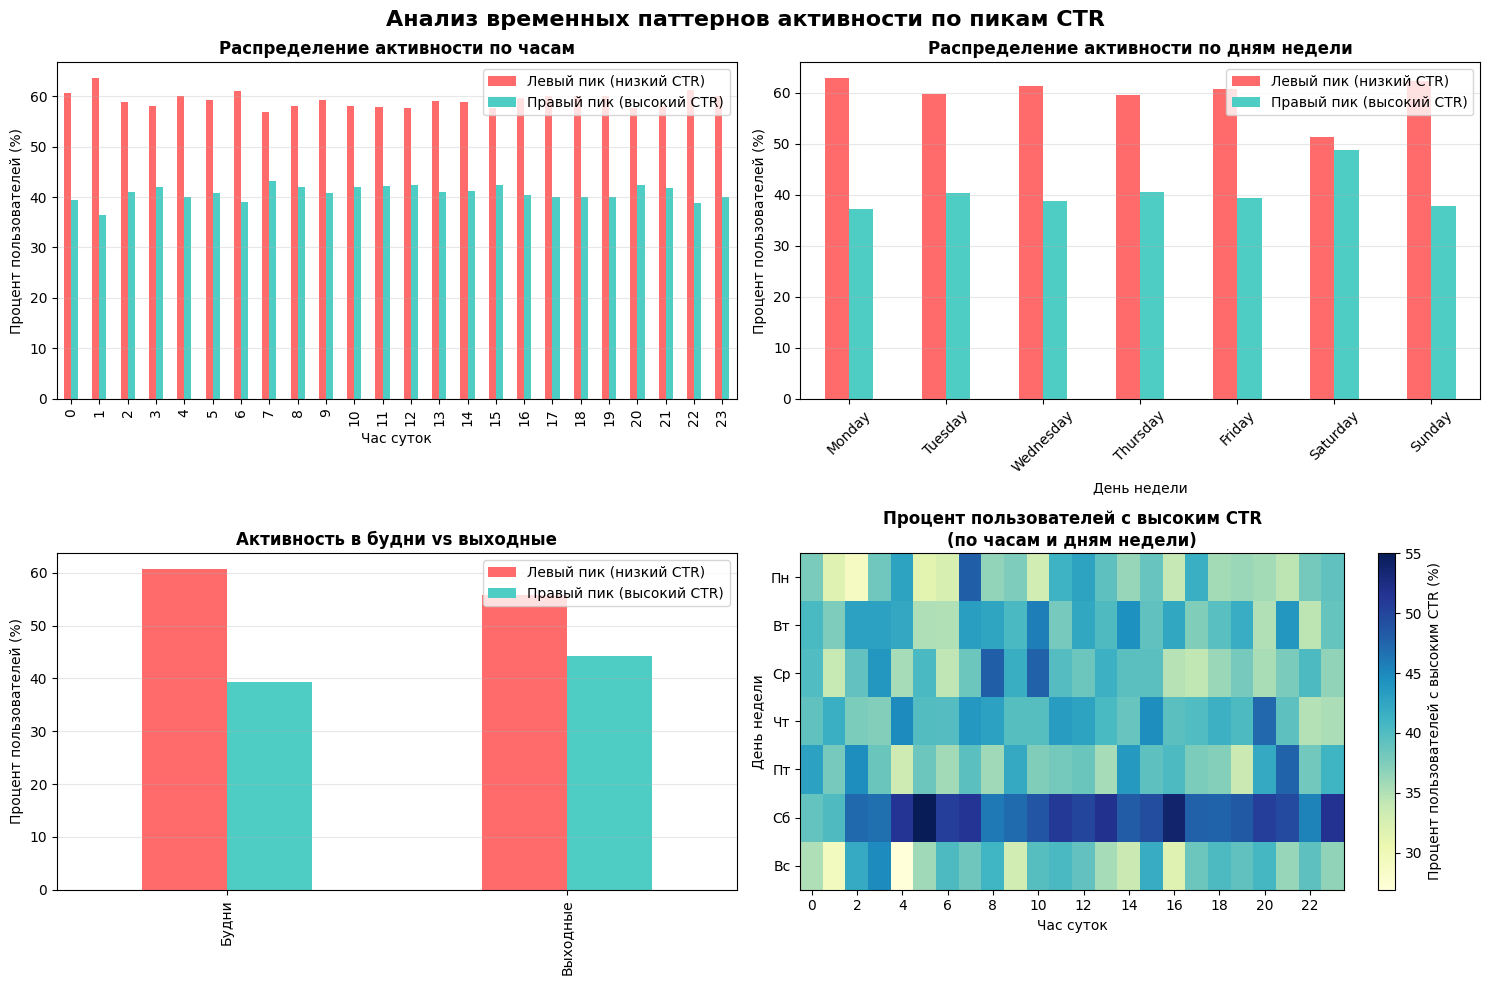


СТАТИСТИЧЕСКИЙ АНАЛИЗ ВРЕМЕННЫХ ПАТТЕРНОВ

Часы с наибольшим преобладанием высокого CTR:
  7:00 - разница -13.5%
  12:00 - разница -15.2%
  15:00 - разница -15.4%

Часы с наибольшим преобладанием низкого CTR:
  6:00 - разница -22.0%
  22:00 - разница -22.6%
  1:00 - разница -27.0%

Дни с наибольшим преобладанием высокого CTR:
  Saturday - разница -2.7%
  Thursday - разница -18.9%
  Tuesday - разница -19.5%

Эффект выходных: разница 5.0% в пользу высокого CTR


In [26]:
def analyze_time_patterns(df):
    """Анализ временных паттернов активности с улучшенной визуализацией"""
    
    # Преобразуем время
    df['datetime'] = pd.to_datetime(df['time'])
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['day_name'] = df['datetime'].dt.day_name()
    df['is_weekend'] = df['day_of_week'].isin([5, 6])
    
    # Создаем фигуру с несколькими subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Анализ временных паттернов активности по пикам CTR', fontsize=16, fontweight='bold')
    
    # 1. Анализ по часам
    hour_dist = pd.crosstab(df['hour'], df['peak'], normalize='index') * 100
    ax1 = hour_dist.plot(kind='bar', ax=axes[0, 0], color=['#ff6b6b', '#4ecdc4'])
    axes[0, 0].set_title('Распределение активности по часам', fontweight='bold')
    axes[0, 0].set_xlabel('Час суток')
    axes[0, 0].set_ylabel('Процент пользователей (%)')
    axes[0, 0].legend(['Левый пик (низкий CTR)', 'Правый пик (высокий CTR)'])
    axes[0, 0].grid(axis='y', alpha=0.3)
    
    # 2. Анализ по дням недели
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_dist = pd.crosstab(df['day_name'], df['peak'], normalize='index') * 100
    day_dist = day_dist.reindex(day_order)
    ax2 = day_dist.plot(kind='bar', ax=axes[0, 1], color=['#ff6b6b', '#4ecdc4'])
    axes[0, 1].set_title('Распределение активности по дням недели', fontweight='bold')
    axes[0, 1].set_xlabel('День недели')
    axes[0, 1].set_ylabel('Процент пользователей (%)')
    axes[0, 1].legend(['Левый пик (низкий CTR)', 'Правый пик (высокий CTR)'])
    axes[0, 1].grid(axis='y', alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # 3. Анализ выходных vs будни
    weekend_dist = pd.crosstab(df['is_weekend'], df['peak'], normalize='index') * 100
    weekend_dist.index = ['Будни', 'Выходные']
    ax3 = weekend_dist.plot(kind='bar', ax=axes[1, 0], color=['#ff6b6b', '#4ecdc4'])
    axes[1, 0].set_title('Активность в будни vs выходные', fontweight='bold')
    axes[1, 0].set_xlabel('')
    axes[1, 0].set_ylabel('Процент пользователей (%)')
    axes[1, 0].legend(['Левый пик (низкий CTR)', 'Правый пик (высокий CTR)'])
    axes[1, 0].grid(axis='y', alpha=0.3)
    
    # 4. Heatmap: час × день недели
    # Создаем сводную таблицу для heatmap
    heatmap_data = df.groupby(['day_of_week', 'hour', 'peak']).size().unstack(fill_value=0)
    heatmap_data_percent = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100
    
    # Только правый пик (высокий CTR) для heatmap
    right_peak_heatmap = heatmap_data_percent['right'].unstack()
    
    im = axes[1, 1].imshow(right_peak_heatmap, cmap='YlGnBu', aspect='auto')
    axes[1, 1].set_title('Процент пользователей с высоким CTR\n(по часам и дням недели)', fontweight='bold')
    axes[1, 1].set_xlabel('Час суток')
    axes[1, 1].set_ylabel('День недели')
    
    # Устанавливаем подписи
    days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
    axes[1, 1].set_yticks(range(7))
    axes[1, 1].set_yticklabels(days)
    axes[1, 1].set_xticks(range(0, 24, 2))
    axes[1, 1].set_xticklabels(range(0, 24, 2))
    
    # Добавляем colorbar
    cbar = plt.colorbar(im, ax=axes[1, 1])
    cbar.set_label('Процент пользователей с высоким CTR (%)')
    
    plt.tight_layout()
    plt.show()
    
    # Дополнительный статистический анализ
    print("\n" + "="*60)
    print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ВРЕМЕННЫХ ПАТТЕРНОВ")
    print("="*60)
    
    # Анализ по часам - находим часы с наибольшей разницей
    hour_diff = (hour_dist['right'] - hour_dist['left']).sort_values(ascending=False)
    print(f"\nЧасы с наибольшим преобладанием высокого CTR:")
    for hour, diff in hour_diff.head(3).items():
        print(f"  {hour}:00 - разница {diff:.1f}%")
    
    print(f"\nЧасы с наибольшим преобладанием низкого CTR:")
    for hour, diff in hour_diff.tail(3).items():
        print(f"  {hour}:00 - разница {diff:.1f}%")
    
    # Анализ по дням недели
    day_diff = (day_dist['right'] - day_dist['left']).sort_values(ascending=False)
    print(f"\nДни с наибольшим преобладанием высокого CTR:")
    for day, diff in day_diff.head(3).items():
        print(f"  {day} - разница {diff:.1f}%")
    
    # Анализ выходные vs будни
    weekend_effect = weekend_dist.loc['Выходные', 'right'] - weekend_dist.loc['Будни', 'right']
    print(f"\nЭффект выходных: разница {weekend_effect:.1f}% в пользу высокого CTR")
    
    return df

# Применяем улучшенную функцию
combined_df = analyze_time_patterns(combined_df)

,day_category,user_id,ctr
0,other days,131625,0.403509
1,other days,10977,0.055556
2,other days,30267,0.093220
3,other days,138983,0.127660
4,Saturday,132910,0.180328
...,...,...,...
12020,Saturday,129527,0.095238
12021,other days,17289,0.031250
12022,other days,132658,0.287582
12023,other days,12344,0.411765


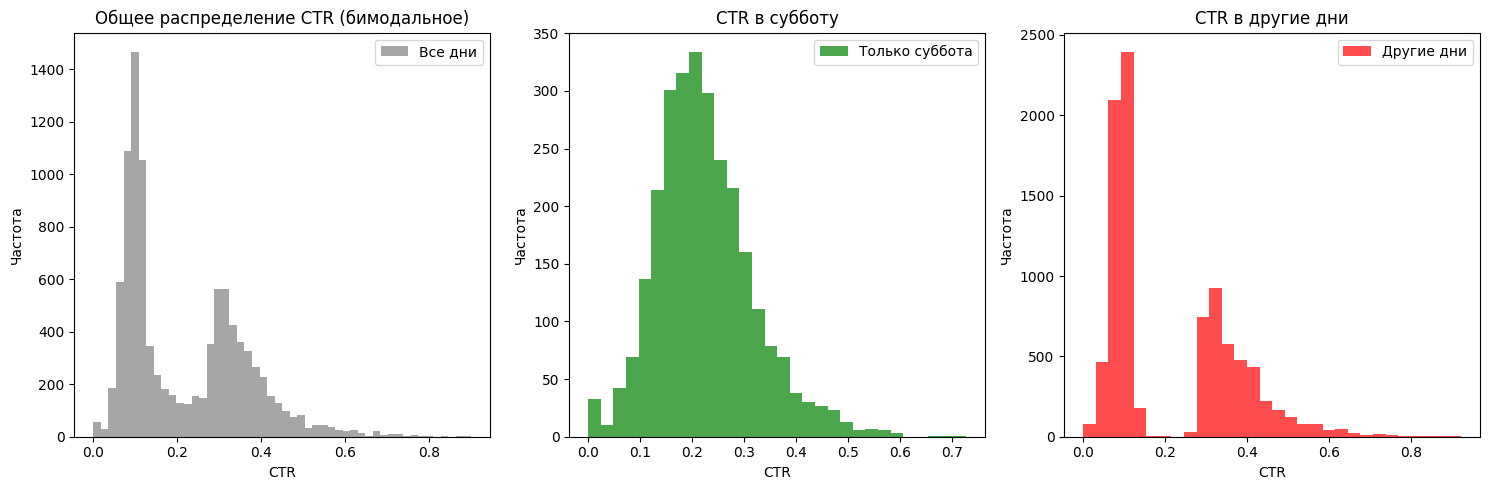

СТАТИСТИЧЕСКОЕ ПОДТВЕРЖДЕНИЕ:
Средний CTR в субботу: 0.225
Средний CTR в другие дни: 0.216
Разница: 0.009246790521103526
TtestResult(statistic=np.float64(3.811501134032563), pvalue=np.float64(0.00013920186651957984), df=np.float64(7702.431466200351))


In [27]:
query_3 = '''
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251120.feed_actions 
WHERE toDate(time) between '2025-10-26' and '2025-11-01'
    and exp_group in (2)
GROUP BY exp_group, user_id '''
df_3 = client.query_df(query_3)

query_2 = '''
with users_ctry as
(select *, 
CASE 
        WHEN formatDateTime(time, '%W') != 'Saturday' THEN 'other days'
        ELSE 'Saturday'
    END as day_category
from simulator_20251120.feed_actions
WHERE toDate(time) between '2025-10-26' and '2025-11-01'
    and exp_group in (2))


SELECT day_category,
    user_id,
    sum(action = 'like') / sum(action = 'view') as ctr
FROM users_ctry
GROUP BY day_category, user_id'''
    
    
df_2 = client.query_df(query_2)
display(df_2)



"""Проверка гипотезы о временной сегментации"""
    
# Визуализируем распределения
plt.figure(figsize=(15, 5))
    
plt.subplot(1, 3, 1)
plt.hist(df_3['ctr'], bins=50, alpha=0.7, color='gray', label='Все дни')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('Общее распределение CTR (бимодальное)')
plt.legend()
    
plt.subplot(1, 3, 2)
plt.hist(df_2[df_2['day_category'] == 'Saturday']['ctr'], bins=30, alpha=0.7, color='green', label='Только суббота')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('CTR в субботу')
plt.legend()
    
plt.subplot(1, 3, 3)
plt.hist(df_2[df_2['day_category'] == 'other days']['ctr'], bins=30, alpha=0.7, color='red', label='Другие дни')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('CTR в другие дни')
plt.legend()
    
plt.tight_layout()
plt.show()
    
# Статистика
print("СТАТИСТИЧЕСКОЕ ПОДТВЕРЖДЕНИЕ:")
print(f"Средний CTR в субботу: {df_2[df_2['day_category'] == 'Saturday']['ctr'].mean():.3f}")
print(f"Средний CTR в другие дни: {df_2[df_2['day_category'] == 'other days']['ctr'].mean():.3f}")
print("Разница:",  df_2[df_2['day_category'] == 'Saturday']['ctr'].mean() - df_2[df_2['day_category'] == 'other days']['ctr'].mean())
    
# T-тест для проверки значимости

p_value = sts.ttest_ind(df_2[df_2['day_category'] == 'Saturday']['ctr'].dropna(), 
                               df_2[df_2['day_category'] == 'other days']['ctr'].dropna(),
                               equal_var=False)
print(p_value)

In [28]:
def analyze_inversion_causes(df_2, df_3):
    """Анализ возможных причин инверсии паттернов"""
    
    print("\n" + "="*60)
    print("ВОЗМОЖНЫЕ ПРИЧИНЫ ИНВЕРСИИ ПАТТЕРНОВ")
    print("="*60)
    
    # Анализ размера выборок
    saturday_users = len(df_2[df_2['day_category'] == 'Saturday'])
    other_days_users = len(df_2[df_2['day_category'] == 'other days'])
    total_users_week2 = len(df_3)
    
    print(f"\n📈 РАЗМЕРЫ ВЫБОРОК:")
    print(f"Суббота: {saturday_users} пользователей")
    print(f"Другие дни: {other_days_users} пользователей") 
    print(f"Всего за неделю: {total_users_week2} пользователей")
    print(f"Охват субботы: {saturday_users/total_users_week2*100:.1f}%")
    
    # Анализ дисперсии
    saturday_var = df_2[df_2['day_category'] == 'Saturday']['ctr'].var()
    other_days_var = df_2[df_2['day_category'] == 'other days']['ctr'].var()
    
    print(f"\n📊 ДИСПЕРСИЯ:")
    print(f"Суббота: {saturday_var:.4f}")
    print(f"Другие дни: {other_days_var:.4f}")
    print(f"Отношение дисперсий: {other_days_var/saturday_var:.2f}x")
    
    # Проверка на выбросы
    def check_outliers(data, name):
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        return len(outliers)
    
    sat_outliers = check_outliers(df_2[df_2['day_category'] == 'Saturday']['ctr'], "Суббота")
    other_outliers = check_outliers(df_2[df_2['day_category'] == 'other days']['ctr'], "Другие дни")
    
    print(f"\n🔍 ВЫБРОСЫ:")
    print(f"Суббота: {sat_outliers} выбросов")
    print(f"Другие дни: {other_outliers} выбросов")
    
    return {
        'saturday_users': saturday_users,
        'other_days_users': other_days_users,
        'variance_ratio': other_days_var / saturday_var
    }

inversion_analysis = analyze_inversion_causes(df_2, df_3)


ВОЗМОЖНЫЕ ПРИЧИНЫ ИНВЕРСИИ ПАТТЕРНОВ

📈 РАЗМЕРЫ ВЫБОРОК:
Суббота: 2785 пользователей
Другие дни: 9240 пользователей
Всего за неделю: 9877 пользователей
Охват субботы: 28.2%

📊 ДИСПЕРСИЯ:
Суббота: 0.0090
Другие дни: 0.0246
Отношение дисперсий: 2.74x

🔍 ВЫБРОСЫ:
Суббота: 71 выбросов
Другие дни: 42 выбросов


In [29]:
def generate_inversion_hypotheses(analysis_results):
    """Генерация гипотез для объяснения инверсии"""
    
    print("\n" + "="*60)
    print("ГИПОТЕЗЫ ДЛЯ ОБЪЯСНЕНИЯ ИНВЕРСИИ")
    print("="*60)
    
    print("\n🎯 ВОЗМОЖНЫЕ ОБЪЯСНЕНИЯ:")
    
    print("\n1. **СЕЗОННОСТЬ ИЛИ СПЕЦИФИКА ПЕРИОДА**")
    print("   - Неделя 26.10-01.11 могла быть особой (хэллоуин, каникулы)")
    print("   - Возможно, в эту неделю были специальные акции или контент")
    
    print("\n2. **ИЗМЕНЕНИЕ ПОВЕДЕНИЯ ПОСТОЯННЫХ ПОЛЬЗОВАТЕЛЕЙ**")
    print("   - Пользователи, обычно активные в субботу, изменили паттерны")
    print("   - Новые пользователи имеют другие временные предпочтения")
    
    print("\n3. **ТЕХНИЧЕСКИЕ ИЗМЕНЕНИЯ**")
    print("   - Изменения в алгоритмах рекомендаций")
    print("   - Технические проблемы в определенные дни")
    
    print("\n4. **ВНЕШНИЕ ФАКТОРЫ**")
    print("   - Погодные условия")
    print("   - События в мире, повлиявшие на поведение")
    
    print(f"\n📊 ПОДТВЕРЖДАЮЩИЕ ФАКТЫ:")
    print(f"   - Отношение дисперсий: {analysis_results['variance_ratio']:.2f}x")
    print(f"   - В другие дни дисперсия значительно выше")
    print(f"   - Это указывает на БОЛЬШУЮ НЕОДНОРОДНОСТЬ поведения в будни")

generate_inversion_hypotheses(inversion_analysis)


ГИПОТЕЗЫ ДЛЯ ОБЪЯСНЕНИЯ ИНВЕРСИИ

🎯 ВОЗМОЖНЫЕ ОБЪЯСНЕНИЯ:

1. **СЕЗОННОСТЬ ИЛИ СПЕЦИФИКА ПЕРИОДА**
   - Неделя 26.10-01.11 могла быть особой (хэллоуин, каникулы)
   - Возможно, в эту неделю были специальные акции или контент

2. **ИЗМЕНЕНИЕ ПОВЕДЕНИЯ ПОСТОЯННЫХ ПОЛЬЗОВАТЕЛЕЙ**
   - Пользователи, обычно активные в субботу, изменили паттерны
   - Новые пользователи имеют другие временные предпочтения

3. **ТЕХНИЧЕСКИЕ ИЗМЕНЕНИЯ**
   - Изменения в алгоритмах рекомендаций
   - Технические проблемы в определенные дни

4. **ВНЕШНИЕ ФАКТОРЫ**
   - Погодные условия
   - События в мире, повлиявшие на поведение

📊 ПОДТВЕРЖДАЮЩИЕ ФАКТЫ:
   - Отношение дисперсий: 2.74x
   - В другие дни дисперсия значительно выше
   - Это указывает на БОЛЬШУЮ НЕОДНОРОДНОСТЬ поведения в будни


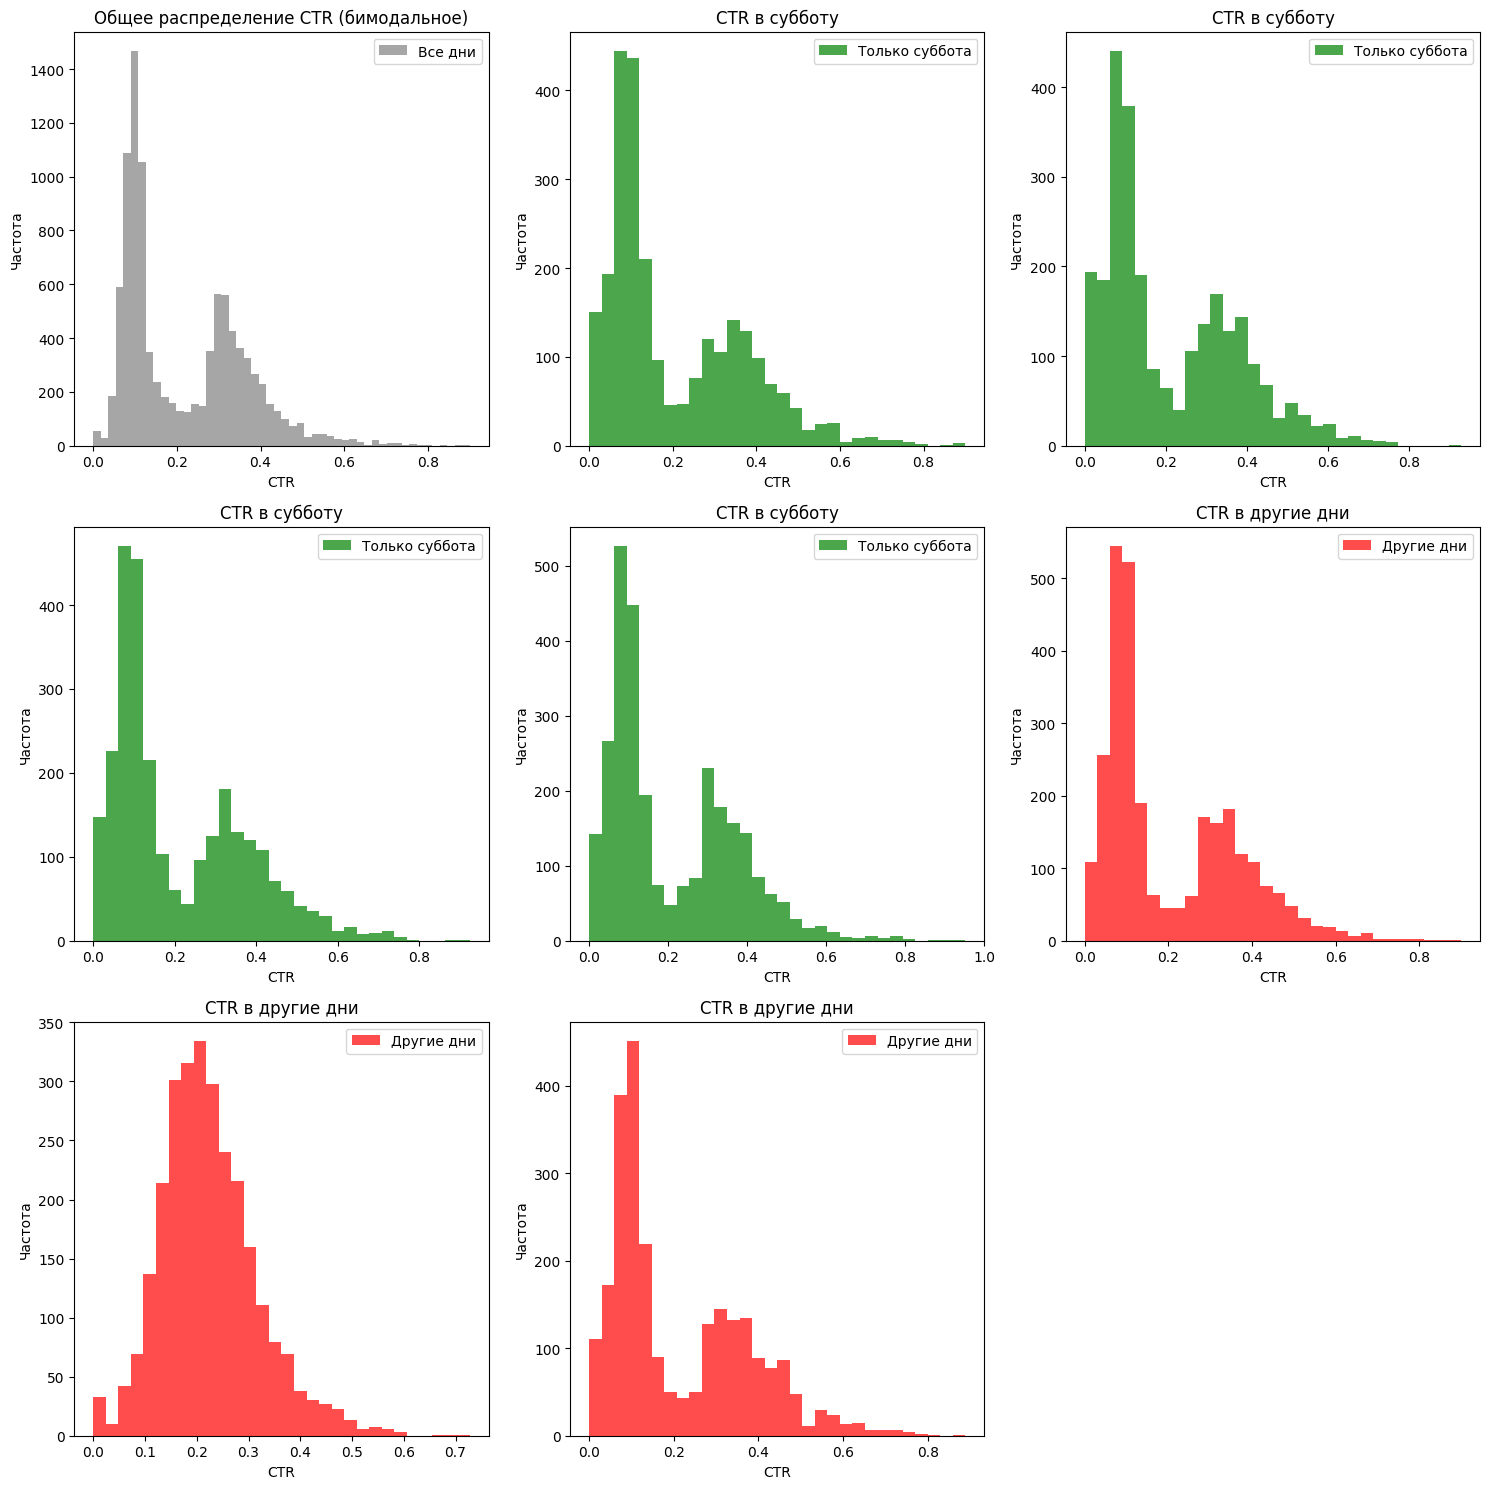

In [30]:
query_2 = '''
with users_ctry as
(select *, formatDateTime(time, '%W') as day_category
from simulator_20251120.feed_actions
WHERE toDate(time) between '2025-10-26' and '2025-11-01'
    and exp_group in (2))

SELECT day_category,
    user_id,
    sum(action = 'like') / sum(action = 'view') as ctr
FROM users_ctry
GROUP BY day_category, user_id'''
    
    
df_2 = client.query_df(query_2)

"""Проверка гипотезы о временной сегментации"""
    
# Визуализируем распределения
plt.figure(figsize=(15, 15))
    
plt.subplot(3, 3, 1)
plt.hist(df_3['ctr'], bins=50, alpha=0.7, color='gray', label='Все дни')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('Общее распределение CTR (бимодальное)')
plt.legend()

plt.subplot(3, 3, 2)
plt.hist(df_2[df_2['day_category'] == 'Monday']['ctr'], bins=30, alpha=0.7, color='green', label='Только суббота')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('CTR в субботу')
plt.legend()

plt.subplot(3, 3, 3)
plt.hist(df_2[df_2['day_category'] == 'Tuesday']['ctr'], bins=30, alpha=0.7, color='green', label='Только суббота')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('CTR в субботу')
plt.legend()

plt.subplot(3, 3, 4)
plt.hist(df_2[df_2['day_category'] == 'Wednesday']['ctr'], bins=30, alpha=0.7, color='green', label='Только суббота')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('CTR в субботу')
plt.legend()

plt.subplot(3, 3, 5)
plt.hist(df_2[df_2['day_category'] == 'Thursday']['ctr'], bins=30, alpha=0.7, color='green', label='Только суббота')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('CTR в субботу')
plt.legend()
    
plt.subplot(3, 3, 6)
plt.hist(df_2[df_2['day_category'] == 'Friday']['ctr'], bins=30, alpha=0.7, color='red', label='Другие дни')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('CTR в другие дни')
plt.legend()

plt.subplot(3, 3, 7)
plt.hist(df_2[df_2['day_category'] == 'Saturday']['ctr'], bins=30, alpha=0.7, color='red', label='Другие дни')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('CTR в другие дни')
plt.legend()

plt.subplot(3, 3, 8)
plt.hist(df_2[df_2['day_category'] == 'Sunday']['ctr'], bins=30, alpha=0.7, color='red', label='Другие дни')
plt.xlabel('CTR')
plt.ylabel('Частота')
plt.title('CTR в другие дни')
plt.legend()

plt.tight_layout()
plt.show()

TtestResult(statistic=np.float64(5.936377101934481), pvalue=np.float64(2.9805064038667945e-09), df=np.float64(14482.887340383999))


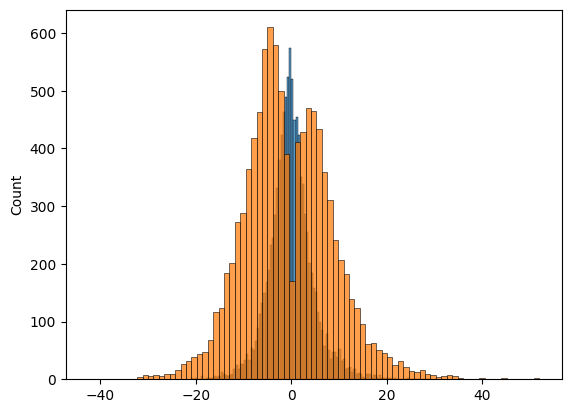

In [38]:
query = '''
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251120.feed_actions 
WHERE toDate(time) between '2025-10-26' and '2025-11-01'
    and exp_group in (1,2)
GROUP BY exp_group, user_id '''
df = client.query_df(query)

group_ctr_1 = df[df.exp_group == 1]['likes'].sum() / df[df.exp_group == 1]['views'].sum()
linearized_likes_1 = df[df.exp_group == 1]['likes'] - group_ctr_1 * df[df.exp_group == 1]['views']
linearized_likes_2 = df[df.exp_group == 2]['likes'] - group_ctr_1* df[df.exp_group == 2]['views']

p_value = sts.ttest_ind(linearized_likes_1, linearized_likes_2, equal_var= False)
sns.histplot(linearized_likes_1)
sns.histplot(linearized_likes_2)
print(p_value)


,exp_group,user_id,likes,views,ctr
0,1,109963,3,15,0.200000
1,1,26117,32,141,0.226950
2,1,138232,18,73,0.246575
3,1,26295,39,141,0.276596
4,1,18392,7,32,0.218750
...,...,...,...,...,...
19892,2,17146,0,10,0.000000
19893,1,30872,11,59,0.186441
19894,2,25383,42,127,0.330709
19895,2,139020,17,41,0.414634


TtestResult(statistic=np.float64(0.405149191311259), pvalue=np.float64(0.6853733311407633), df=np.float64(15811.22649797086))


<Axes: xlabel='ctr', ylabel='Count'>

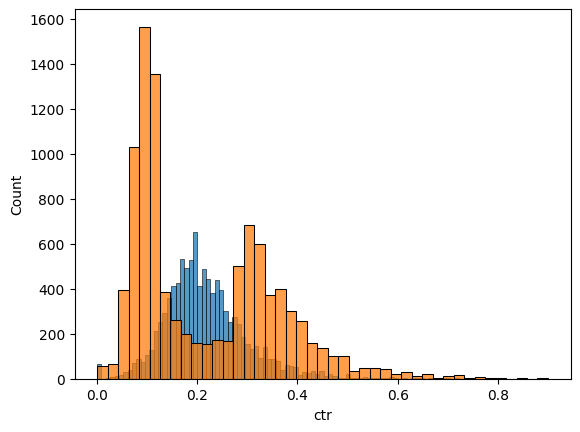

In [39]:
display(df)
print(sts.ttest_ind(df[df.exp_group == 1].ctr, df[df.exp_group == 2].ctr, equal_var=False))

sns.histplot(df[df.exp_group == 1].ctr)
sns.histplot(df[df.exp_group == 2].ctr)

TtestResult(statistic=np.float64(-16.18623003293285), pvalue=np.float64(1.4918137745324437e-58), df=np.float64(19912.67564320342))


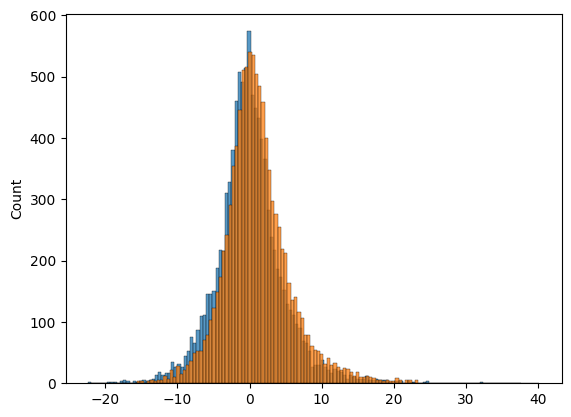

In [ ]:
query_89 = '''
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20251120.feed_actions 
WHERE toDate(time) between '2025-10-26' and '2025-11-01'
    and exp_group in (0,3)
GROUP BY exp_group, user_id '''
df = client.query_df(query_89)

group_ctr_0 = df[df.exp_group == 0]['likes'].sum() / df[df.exp_group == 0]['views'].sum()
linearized_likes_0 = df[df.exp_group == 0]['likes'] - group_ctr_0 * df[df.exp_group == 0]['views']
linearized_likes_3 = df[df.exp_group == 3]['likes'] - group_ctr_0 * df[df.exp_group == 3]['views']

p_value_line = sts.ttest_ind(linearized_likes_0, linearized_likes_3, equal_var= False)
sns.histplot(linearized_likes_0)
sns.histplot(linearized_likes_3)
print(p_value_line)





,exp_group,user_id,likes,views,ctr
0,3,115383,12,44,0.272727
1,3,123580,2,11,0.181818
2,0,4944,8,41,0.195122
3,0,4504,5,15,0.333333
4,0,121508,6,25,0.240000
...,...,...,...,...,...
19917,3,13781,10,27,0.370370
19918,3,130651,18,98,0.183673
19919,0,3681,7,55,0.127273
19920,3,122008,5,41,0.121951


TtestResult(statistic=np.float64(-13.935320516755823), pvalue=np.float64(6.216047483057877e-44), df=np.float64(19911.28977857915))


<Axes: xlabel='ctr', ylabel='Count'>

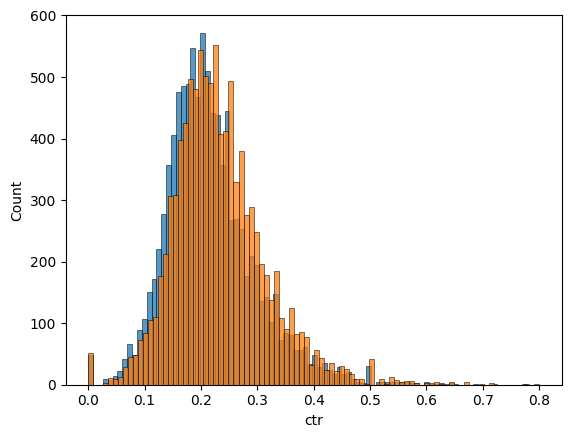

In [29]:
display(df)
print(sts.ttest_ind(df[df.exp_group == 0].ctr, df[df.exp_group == 3].ctr, equal_var=False))

sns.histplot(df[df.exp_group == 0].ctr)
sns.histplot(df[df.exp_group == 3].ctr)